# Phase 3 - Model Development (Classification)

*Hospital Operations & Revenue Risk Intelligence Platform*

**Goal:** two calibrated, time-validated classifiers.

* **Model A - visit risk** (`risk_score` Low/Medium/High): operational + clinical
  + patient-history features only, for staffing / bed planning / prioritisation.
* **Model B - pre-submission claim outcome** (`claim_status` Paid/Pending/
  Rejected): everything knowable before the claim is filed, for pre-submission
  denial triage.

This notebook is thin: all reusable logic lives in `capstone.modeling`; the
per-finding charts are in `phase3_models/make_charts.py` and the report
assembler in `phase3_models/report.py`. It runs top-to-bottom from a clean
kernel and is safe to re-run - it rebuilds every artefact, CSV, chart and
`PHASE3_FINDINGS.md`.

**Input:** `phase2_eda/output/feature_frame.parquet` (Phase 2 as-of feature
matrix) + `capstone.features` leakage register.
**Outputs:** `phase3_models/models/` (pipelines, calibrated wrappers,
`training_manifest.json`), `phase3_models/output/` (predictions, metrics,
`charts/`), `phase3_models/PHASE3_FINDINGS.md`.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from capstone import features as feat, modeling as M, viz
import make_charts, report

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
viz.apply_house_style()

HERE = Path.cwd()
MODELS = HERE / "models"; MODELS.mkdir(exist_ok=True)
OUT = HERE / "output"; (OUT / "charts").mkdir(parents=True, exist_ok=True)
PARQUET = HERE.parent / "phase2_eda" / "output" / "feature_frame.parquet"
FINDINGS_MD = HERE / "PHASE3_FINDINGS.md"

## 1. Load the Phase 2 feature frame and split on `visit_date`

The as-of matrix from Phase 2 - one row per visit, patient/provider history counted only from strictly earlier visits. Split is calendar-anchored: 9 months train, 1 validate, 2 test. No shuffle.

In [2]:
df = pd.read_parquet(PARQUET)
df["visit_date"] = pd.to_datetime(df["visit_date"])
splits = M.time_split(df)
splits.describe()

,split,rows,start,end
0,train,18665,2025-01-20,2025-10-19
1,val,2075,2025-10-20,2025-11-19
2,test,4260,2025-11-20,2026-01-20


### 1.1 Leakage self-check

The Phase 2 register is the contract. `train_model` re-runs this and refuses to fit if it fails.

In [3]:
violations = feat.leakage_violations(splits.train)
assert not violations, violations
for m in ("A", "B"):
    n, c = M.feature_lists(splits.train, m)
    print(f"Model {m}: {len(n)} numeric + {len(c)} categorical features, 0 leakage violations")

Model A: 13 numeric + 9 categorical features, 0 leakage violations
Model B: 16 numeric + 13 categorical features, 0 leakage violations


## 2. Train both models

Four candidates each - majority baseline, domain simple-rule baseline,
regularised logistic regression, gradient-boosted trees - all evaluated on the
held-out test window. A learned model is shipped only if it beats the majority
baseline's balanced accuracy by >= 0.02 and the simple rule's macro-F1;
otherwise the majority baseline ships as a base-rate monitor. The selected model
is then calibrated (sigmoid) on the validation month.

In [4]:
results = {k: M.train_model(splits, k) for k in ("A", "B")}
for k, r in results.items():
    print(f"Model {k}: selected '{r.chosen}'  |  "
          f"beats majority balanced-acc: {r.beats_majority_balanced_accuracy}  |  "
          f"beats simple-rule macro-F1: {r.beats_simple_rule_macro_f1}")

Model A: selected 'majority'  |  beats majority balanced-acc: False  |  beats simple-rule macro-F1: False
Model B: selected 'gbm'  |  beats majority balanced-acc: True  |  beats simple-rule macro-F1: True


### 2.1 Candidate metrics on the test window

In [5]:
for k, r in results.items():
    display(Markdown(f"**Model {k} - {r.target.replace('target_', '')}**"))
    display(r.metrics_frame().round(4))

**Model A - risk_score**

,candidate,accuracy,balanced_accuracy,macro_f1,recall_high
0,majority,0.4972,0.3333,0.2214,0.0000
1,simple_rule,0.4972,0.3333,0.2214,0.0000
2,logreg,0.3805,0.3268,0.3253,0.2063
3,gbm,0.2547,0.3261,0.2497,0.6083


**Model B - claim_status**

,candidate,accuracy,balanced_accuracy,macro_f1,recall_rejected
0,majority,0.6021,0.3333,0.2505,0.0000
1,simple_rule,0.4681,0.4156,0.3185,0.6151
2,logreg,0.3446,0.3915,0.3356,0.4062
3,gbm,0.3965,0.4360,0.3673,0.6562


## 3. Charts and findings

Every finding below is backed by a house-style chart (`capstone.viz`); `make_charts.build_all` also writes the CSV exports.

In [6]:
charts = make_charts.build_all(results)
_C = {k: p for k, p, _ in charts}
list(_C)

['target_balance',
 'feature_signal_recap',
 'candidate_comparison_a',
 'candidate_comparison_b',
 'costly_class_recall',
 'confusion_matrix_a',
 'confusion_matrix_b',
 'calibration_b']

### 3.1 Targets and the performance ceiling

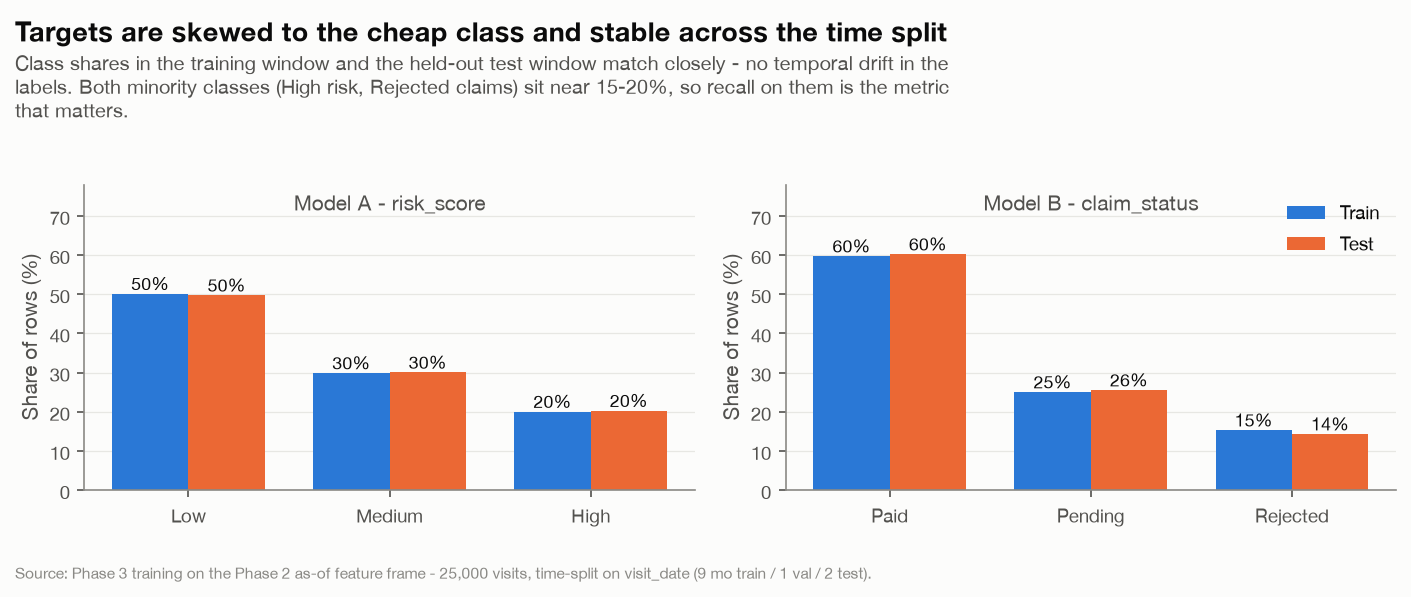

In [7]:
Image(str(_C["target_balance"]))

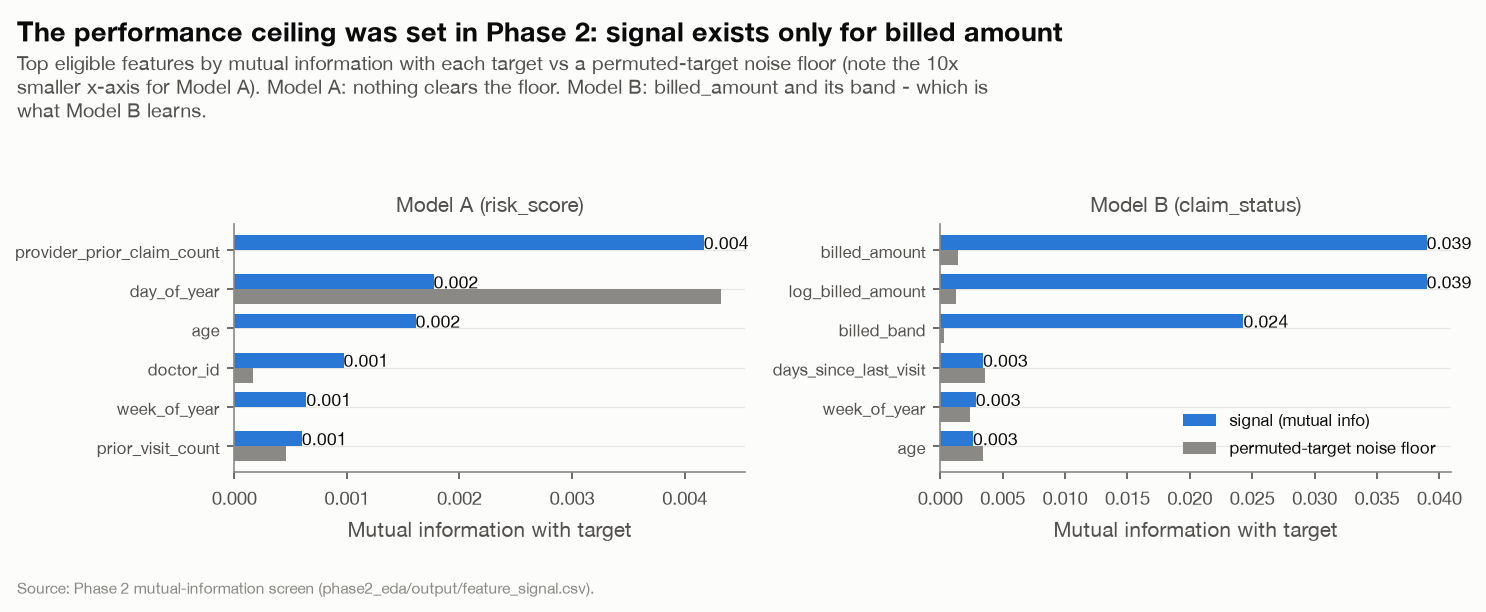

In [8]:
Image(str(_C["feature_signal_recap"]))

### 3.2 Model A - no trained model separates the risk classes

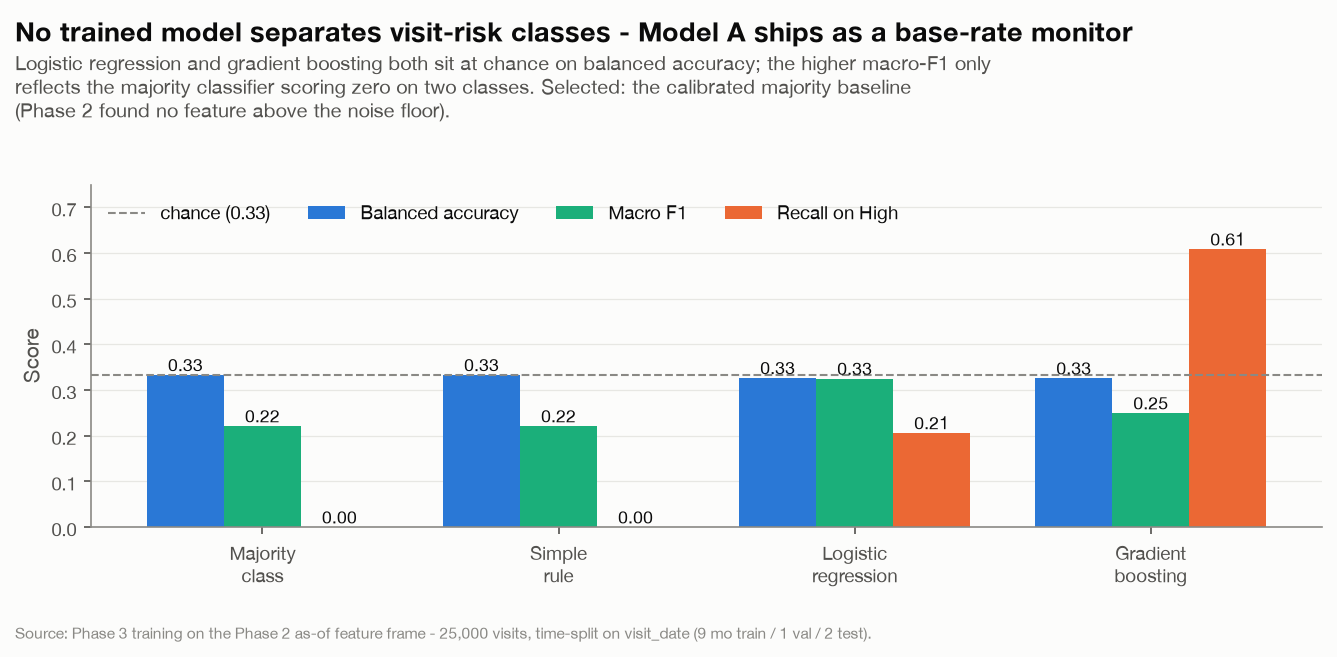

In [9]:
Image(str(_C["candidate_comparison_a"]))

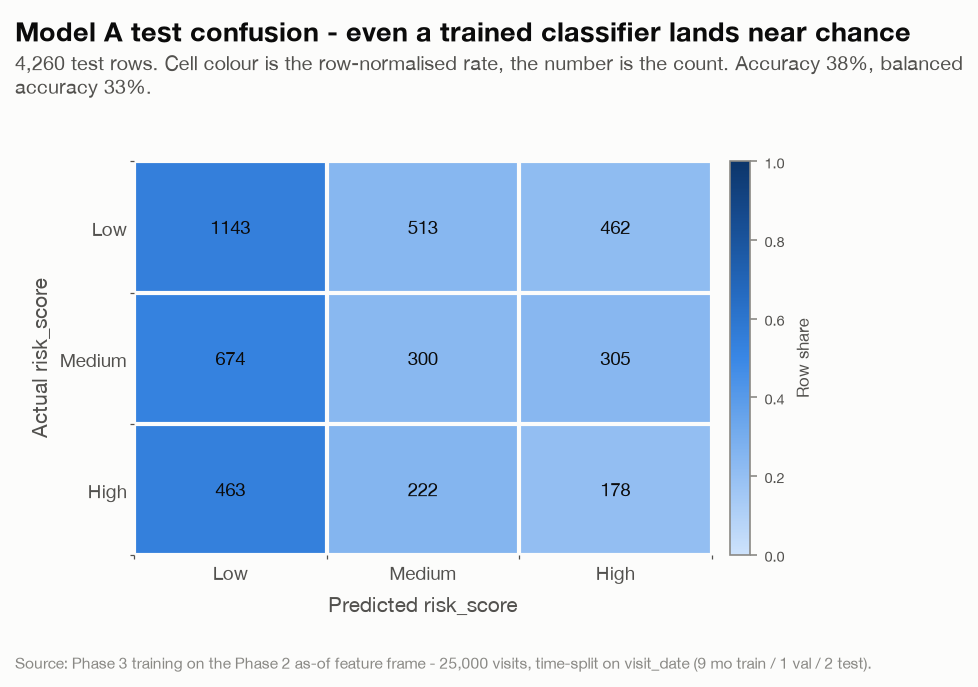

In [10]:
Image(str(_C["confusion_matrix_a"]))

### 3.3 Model B - gradient boosting for pre-submission triage

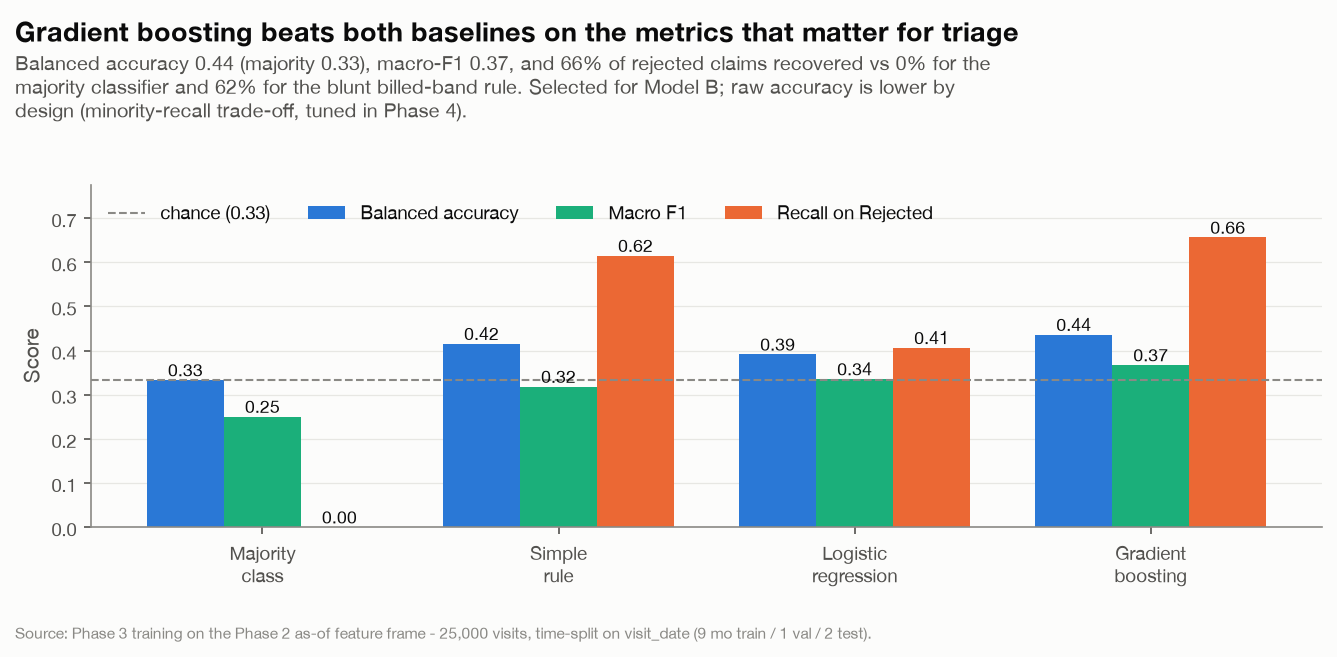

In [11]:
Image(str(_C["candidate_comparison_b"]))

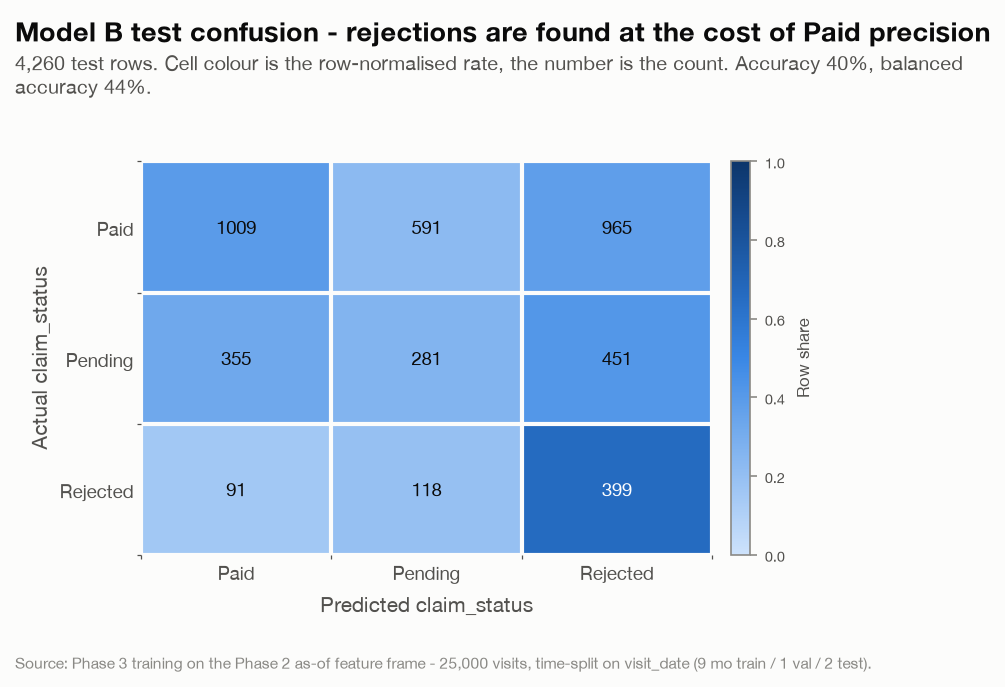

In [12]:
Image(str(_C["confusion_matrix_b"]))

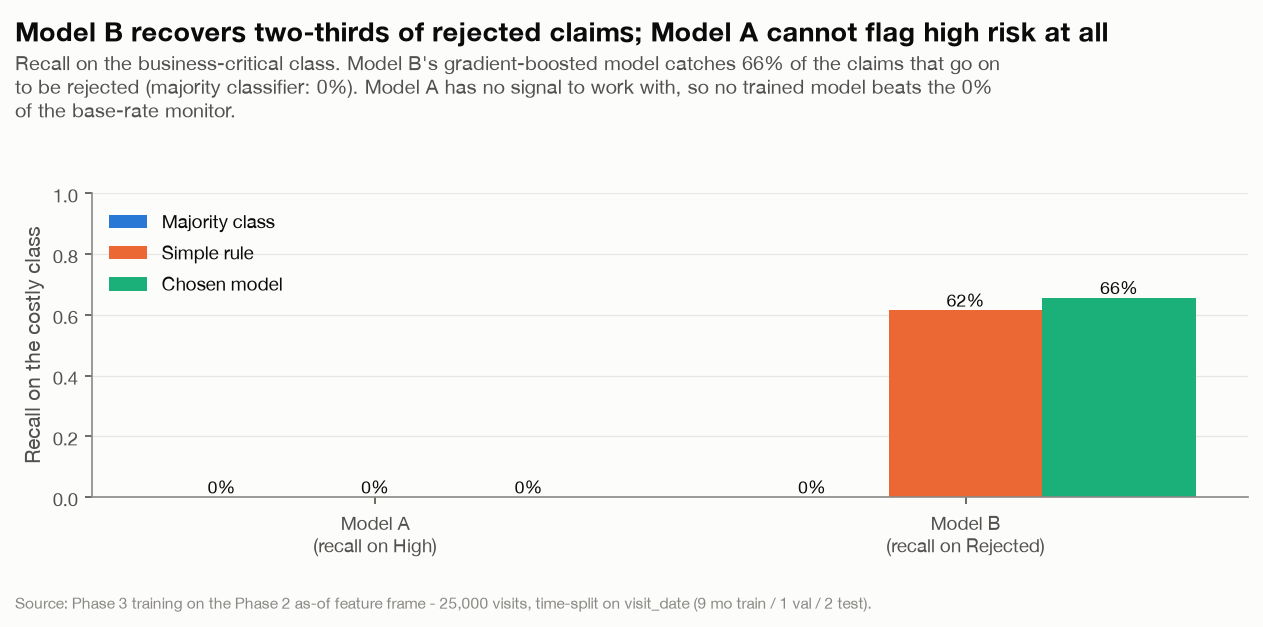

In [13]:
Image(str(_C["costly_class_recall"]))

### 3.4 Probability calibration

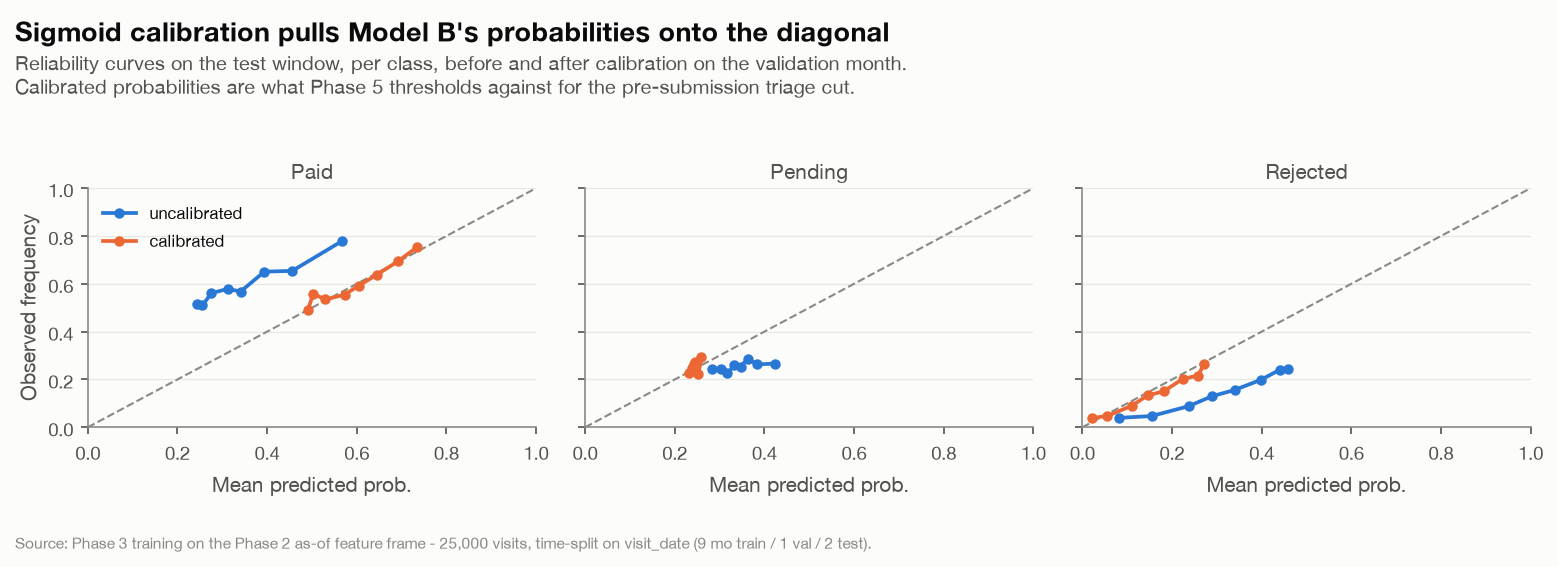

In [14]:
Image(str(_C["calibration_b"]))

## 4. Persist artefacts

Pipelines + calibrated wrappers + a portable `training_manifest.json` (relative paths, model version, per-model feature lists, every candidate's metrics).

In [15]:
window = {
    "start": splits.train["visit_date"].min().date().isoformat(),
    "end": splits.test["visit_date"].max().date().isoformat(),
    "rows": int(len(df)),
    "split": "9 months train / 1 validate / 2 test, calendar-anchored on visit_date",
}
provenance = {
    "source": "phase2_eda/output/feature_frame.parquet",
    "rows": int(len(df)),
    "modified": pd.Timestamp(PARQUET.stat().st_mtime, unit="s").isoformat(),
}
manifest_path = M.save_artifacts(results, MODELS, data_window=window,
                                 feature_frame_provenance=provenance)
print("wrote", manifest_path.relative_to(HERE))

wrote models/training_manifest.json


### 4.1 Reload parity - predict from a clean load

In [16]:
parity = M.reload_parity(MODELS, results)
display(parity)
assert parity["matches_in_memory_exactly"].all()

,model,artefact,n_test_rows,matches_in_memory_exactly
0,Model A,pipeline (labels),4260,True
1,Model A,calibrated (probabilities),4260,True
2,Model B,pipeline (labels),4260,True
3,Model B,calibrated (probabilities),4260,True


## 5. Generate PHASE3_FINDINGS.md

In [17]:
import json
manifest = json.loads(manifest_path.read_text())
path = report.write_findings(results, charts, manifest, parity, FINDINGS_MD)
print("wrote", path.relative_to(HERE))

wrote PHASE3_FINDINGS.md


## 6. Exit criteria

- [x] Time-based split on `visit_date` (9 / 1 / 2 months), no shuffle.
- [x] `ColumnTransformer` + model pipelines; logistic-regression and
      gradient-boosted-tree candidates, both with balanced class weights.
- [x] Probability calibration (sigmoid) on the validation month, both models.
- [x] Models + pipelines + `training_manifest.json` persisted with relative
      paths and a model version; artefacts reload and predict exactly.
- [x] Leakage register (`capstone.features.leakage_violations`) holds for both
      feature sets.
- [x] **Model B** beats the majority **and** simple-rule baselines on balanced
      accuracy, macro-F1 and rejected-claim recall.
- [ ] **Model A** cannot beat the baselines - no signal (Phase 2). Shipped as a
      calibrated base-rate monitor, documented in `PHASE3_FINDINGS.md`.
- [ ] Neither model beats the baseline **on raw accuracy** - the wrong bar for a
      skewed target; Model B trades accuracy for a two-thirds rejected-claim
      catch rate.

**Hand-off to Phase 4:** the persisted models + calibrated wrappers +
`training_manifest.json` + test predictions with calibrated probabilities.
Phase 4 does explainability, fairness, the leakage ablation, ROC/PR curves,
the operating-threshold choice and the model cards.